# Beschreibung #

# ICA-„Eigenwerte" (Nicht-Gaussianitäts-Spektrum) für Tennessee Eastman Process (TEP)

Dieses Notebook berechnet für jede Fehlerklasse (`faultNumber` 0-20) und jeden
Simulationslauf (`simulationRun`) ein **ICA-basiertes Spektrum** des jeweiligen
Runs und fasst dieses anschließend über die 500 Läufe pro Fehlerklasse mittels
Mittelwert und Standardabweichung zusammen. Struktur und Konventionen sind
identisch zu `PCA_eigenwerte.ipynb`/`DyCA_Eigenwerte.ipynb`.

**Datensatz**

Kaggle "tep-csv" (afrniomelo):
https://www.kaggle.com/datasets/afrniomelo/tep-csv

- `TEP_FaultFree_Training.csv`  (faultNumber = 0)
- `TEP_Faulty_Training.csv`     (faultNumber = 1..20)

Beide Dateien müssen im aktuellen Arbeitsverzeichnis liegen.

Eigenschaften des Datensatzes (laut Kaggle-Doku):
- Sampling-Intervall: alle 3 Minuten.
- Training: 500 Samples pro Run (= 25 h Simulationsdauer).
- Faulty Training: Fehler wird **1 Stunde nach Simulationsstart** injiziert
  → 60 min / 3 min = **20 Samples Vorlauf**, erstes Post-Fault-Sample ist
  `sample == 21`.

**Konzeptioneller Unterschied zu PCA / DyCA — und die Designentscheidung**

**ICA liefert keine Eigenwerte.** FastICA schätzt maximal nicht-gaussische,
statistisch unabhängige Quellen; die Komponenten sind unsortiert und tragen
keine Varianz-Rangfolge (das Whitening macht alle Komponenten gleich groß).
Als Eigenwert-Analogon exportiert dieses Notebook deshalb das
**Nicht-Gaussianitäts-Spektrum**: die **Exzess-Kurtosis** jeder geschätzten
Komponente, absteigend nach |Kurtosis| sortiert (`ica_1 … ica_12`).

Begründung dieser Wahl:
- FastICA optimiert genau Nicht-Gaussianität — die Kurtosis ist deren
  klassisches skalares Maß und damit das natürliche „so stark ist diese
  Komponente" der Methode (analog zu „so viel Varianz erklärt diese
  Komponente" bei PCA).
- Das **Vorzeichen bleibt erhalten**: positiv = super-gaussisch (impulsiv,
  Spikes/Sprünge — typisch für viele Fault-Signaturen), negativ =
  sub-gaussisch (oszillierend/gleichverteilt). Es trägt Information und
  ist gegen die Vorzeichen-Willkür der ICA-Komponenten immun (4. Moment).
- Die Alternative — die Eigenwerte des Whitening-Schritts — wäre nur eine
  Dublette des PCA-Notebooks.

**Weitere Festlegungen**

- `N_ICA = 12` Komponenten pro Run: deckt den Bereich 4–12 ab, der in den
  übrigen Notebooks verwendet wird. Alle 52 Komponenten aus nur 480 Samples
  zu schätzen wäre numerisch instabil und deutlich langsamer.
- FastICA ist mit `random_state = 42` **deterministisch** (gleiches Ergebnis
  bei jedem Lauf); `max_iter = 1000`, `tol = 1e-3`.
- **Nicht-Konvergenz ist kein Ausfall:** FastICA liefert dann eine
  teil-konvergierte Rotation, die verwendet wird. Die Konvergenz wird pro
  Run mitprotokolliert (Spalte `converged`) und in der Diagnose-Zelle pro
  Fehlerklasse ausgewiesen. Nur echte Exceptions führen — wie im
  DyCA-Notebook — zum Überspringen des Runs.
- **Aktive Vorverarbeitung: `X_scaled = X - X.mean()`** (`global_mean`,
  exakt die Konvention der anderen Notebooks); den Mittelwert zentriert
  FastICA zusätzlich intern. Anders als bei CVA ist die Skalierung hier
  **nicht** folgenlos: das Whitening ist PCA-basiert — ohne
  Standardisierung dominieren die varianzstärksten Rohvariablen. Ein
  `StandardScaler` wird trotzdem auf Normalbetrieb gefittet und steht als
  Alternative bereit (`X_scaled = scaler.transform(X)`); dann gehen alle
  Variablen gleichgewichtet ein.
- Bei Fehlerklassen 1-20 werden die **Pre-Fault-Samples** (`sample < 21`)
  verworfen: Fault 0 nutzt 500, Fault 1-20 jeweils 480 Beobachtungen.
- Über die Läufe einer Fehlerklasse werden für jeden Spektrums-Index
  Mittelwert und Standardabweichung gebildet.

**Hinweis zu den Plots:** Das Spektrum läuft über die Komponenten-Indizes
1…12 (wie bei PCA/DyCA über die Komponenten), die Werte können aber
**negativ** sein (sub-gaussisch). Die Plots nutzen deshalb standardmäßig die
lineare Skala, und der Variationskoeffizient wird mit |Mittelwert| im Nenner
gebildet.


# Imports #

In [1]:
# !pip install matplotlib numpy pandas scikit-learn scipy tqdm

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA
from sklearn.exceptions import ConvergenceWarning

# Optional: Fortschrittsbalken fuer lange Schleifen
try:
    from tqdm.auto import tqdm
    tqdm_available = True
except ImportError:
    tqdm_available = False

plt.rcParams["figure.figsize"] = (16, 4)
plt.rcParams["font.size"] = 10

# Parameter #

In [2]:
# ===== Pfade zu den TEP-CSV-Dateien =====
PATH_FAULTFREE_TRAIN = "TEP_FaultFree_Training.csv"
PATH_FAULTY_TRAIN    = "TEP_Faulty_Training.csv"

# ===== Prozessvariablen (wie im PCA-/DyCA-Notebook) =====
XMEAS_COLS = [f"xmeas_{i}" for i in range(1, 42)]
XMV_COLS   = [f"xmv_{i}"   for i in range(1, 12)]
PROC_COLS  = XMEAS_COLS + XMV_COLS

META_COLS  = ["faultNumber", "simulationRun", "sample"]

# ===== ICA-Parameter =====
# Anzahl der pro Run geschaetzten unabhaengigen Komponenten. 12 deckt
# den in den uebrigen Notebooks verwendeten Bereich 4..12 ab; alle 52
# Komponenten aus 480 Samples zu schaetzen waere instabil und langsam.
N_ICA = 12

# FastICA-Einstellungen. random_state fixiert -> deterministisch.
# tol=1e-3 (statt sklearn-Default 1e-4) verbessert die Konvergenzrate
# auf den verrauschten TEP-Runs; Nicht-Konvergenz wird unten gezaehlt,
# aber nicht als Ausfall behandelt (siehe Beschreibung).
ICA_MAX_ITER     = 1000
ICA_TOL          = 1e-3
ICA_RANDOM_STATE = 42

# Erster Sample-Index, der als 'post-fault' gilt (siehe Beschreibung).
PRE_FAULT_CUTOFF = 21

# Daten laden & Spalten prüfen #

In [3]:
# ============================================================
# Trainingsdaten laden
# ============================================================
# Beide Trainings-CSVs muessen im aktuellen Arbeitsverzeichnis liegen.
#   - TEP_FaultFree_Training.csv : nur faultNumber == 0
#     -> 500 simulationRuns x 500 samples = 250 000 Zeilen
#   - TEP_Faulty_Training.csv    : faultNumber 1..20
#     -> 20 faults x 500 runs x 500 samples = 5 000 000 Zeilen

df_ff_train     = pd.read_csv(PATH_FAULTFREE_TRAIN)
df_faulty_train = pd.read_csv(PATH_FAULTY_TRAIN)

# Nur die benoetigten Spalten behalten (Metadaten + Prozessvariablen).
df_ff_train     = df_ff_train[META_COLS + PROC_COLS]
df_faulty_train = df_faulty_train[META_COLS + PROC_COLS]

print("FaultFree_Training shape:", df_ff_train.shape)
print("Faulty_Training shape   :", df_faulty_train.shape)

# ------------------------------------------------------------
# Spalten-Check
# ------------------------------------------------------------
for col in META_COLS:
    if col not in df_ff_train.columns:
        raise ValueError(f"Spalte {col} fehlt in TEP_FaultFree_Training.csv")
    if col not in df_faulty_train.columns:
        raise ValueError(f"Spalte {col} fehlt in TEP_Faulty_Training.csv")

print("Anzahl Prozessvariablen:", len(PROC_COLS))
print("Beispiel-Variablen:", PROC_COLS[:5])

FaultFree_Training shape: (250000, 55)
Faulty_Training shape   : (5000000, 55)
Anzahl Prozessvariablen: 52
Beispiel-Variablen: ['xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5']


# StandardScaler auf FaultFree_Training fitten (wird in der Schleife angewandt) #

In [4]:
# ============================================================
# StandardScaler auf FaultFree_Training (Normalbetrieb) fitten
# ============================================================
# Der Scaler ist aktuell UNGENUTZT: aktiv ist X_scaled = X - X.mean()
# (global_mean) in run_ica_on_group. Anders als bei CVA ist die Wahl
# NICHT folgenlos: das Whitening der FastICA ist PCA-basiert - ohne
# Standardisierung dominieren die varianzstaerksten Rohvariablen (wie
# bei PCA). Umschalten kostet nur die eine Zeile dort.

scaler = StandardScaler()
scaler.fit(df_ff_train[PROC_COLS].values)

print("StandardScaler auf FaultFree_Training angepasst.")
print("  Anzahl Features:        ", len(PROC_COLS))
print("  Mittelwerte (Auszug):   ", np.round(scaler.mean_[:5], 4))
print("  Std-Werte (Auszug):     ", np.round(scaler.scale_[:5], 4))

StandardScaler auf FaultFree_Training angepasst.
  Anzahl Features:         52
  Mittelwerte (Auszug):    [2.5050000e-01 3.6637857e+03 4.5088198e+03 9.3471000e+00 2.6902200e+01]
  Std-Werte (Auszug):      [3.09000e-02 3.40063e+01 3.92153e+01 8.57000e-02 2.11500e-01]


# Trainingsdaten zusammenführen (Fault 0-20) #

In [5]:
# ============================================================
# Trainingsdaten zusammenfuehren (Fault 0..20 in EINEM DataFrame)
# ============================================================
# Eine Schleife laeuft anschliessend ueber alle Kombinationen
# (faultNumber, simulationRun).
#
# Globale Sortierung nach (Fault, Run, Sample): die Kurtosis selbst ist
# permutationsinvariant, aber eine feste Zeilenreihenfolge macht die
# FastICA-Schaetzung reproduzierbar (gleiche Daten in gleicher Ordnung
# + fester random_state -> identisches Ergebnis).

df_all = pd.concat([df_ff_train, df_faulty_train], ignore_index=True)
df_all = df_all.sort_values(
    ["faultNumber", "simulationRun", "sample"]
).reset_index(drop=True)

print("Kombinierte Trainingsdaten shape:", df_all.shape)
print("FaultNumbers im kombinierten Datensatz:",
      sorted(df_all["faultNumber"].unique()))

Kombinierte Trainingsdaten shape: (5250000, 55)
FaultNumbers im kombinierten Datensatz: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


# Funktion: ICA-Spektrum pro Run #

In [6]:
def run_ica_on_group(
    group: pd.DataFrame,
    scaler: StandardScaler,
    proc_cols: list,
    n_components: int = N_ICA,
):
    """
    Fuehrt FastICA auf einem einzelnen (faultNumber, simulationRun)-
    Subsample aus und gibt das Nicht-Gaussianitaets-Spektrum zurueck.

    Vorgehen
    --------
    1. FastICA mit n_components Komponenten fitten (Whitening intern,
       'unit-variance' -> alle Quellen haben Varianz 1, die Kurtosis ist
       dadurch skalenfrei vergleichbar).
    2. Exzess-Kurtosis jeder geschaetzten Quelle berechnen
       (Fisher-Definition: Gauss = 0).
    3. Absteigend nach |Kurtosis| sortieren - die staerkste
       Nicht-Gaussianitaet zuerst (Analogon zu "groesster Eigenwert
       zuerst" bei PCA/DyCA). Das VORZEICHEN bleibt erhalten
       (positiv = super-gaussisch/impulsiv, negativ = sub-gaussisch).

    Parameter
    ---------
    group : pd.DataFrame
        Genau EIN Run, Zeilen = Samples.
    scaler : StandardScaler
        Auf FaultFree gefittet, hier aktuell UNGENUTZT (aktiv ist
        X_scaled = X - X.mean()); erst beim Umschalten gebraucht.
    proc_cols : list[str]
        Prozessvariablen-Spalten (xmeas_*, xmv_*).
    n_components : int
        Anzahl der geschaetzten unabhaengigen Komponenten.

    Rueckgabewert
    -------------
    (kurt_sorted, converged) : (np.ndarray, bool)
        kurt_sorted: Exzess-Kurtosis-Werte, shape (n_components,),
        absteigend nach |Wert| sortiert, Vorzeichen erhalten.
        converged: False, wenn FastICA eine ConvergenceWarning
        ausgegeben hat (Ergebnis wird trotzdem verwendet).
    """

    # 0) Defensive Sortierung nach 'sample' - fuer die Kurtosis egal,
    # aber sie haelt die FastICA-Schaetzung deterministisch (gleiche
    # Zeilenordnung bei jedem Aufruf).
    if "sample" in group.columns:
        group = group.sort_values("sample")

    # 1) Messmatrix dieses Runs extrahieren.
    # Shape: (n_samples, n_features) = z.B. (480, 52)
    X = group[proc_cols].values.astype(np.float64)

    # 2) Vorverarbeitung: Abzug des skalaren Gesamtmittelwerts
    # (global_mean, Konvention aller Eigenwert-Notebooks). Die fehlende
    # Skalierung wirkt wie bei PCA auf das Whitening; den Mittelwert
    # zentriert FastICA zusaetzlich intern.
    X_scaled = X - X.mean()  # global_mean aktiv | Alternative: X_scaled = scaler.transform(X)

    # 3) FastICA fitten. ConvergenceWarnings werden abgefangen und als
    # Flag zurueckgemeldet statt den Lauf zu verwerfen - eine teil-
    # konvergierte Loesung ist immer noch eine gueltige Rotation der
    # gewhiteten Daten.
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        ica = FastICA(n_components=n_components, whiten="unit-variance",
                      max_iter=ICA_MAX_ITER, tol=ICA_TOL,
                      random_state=ICA_RANDOM_STATE)
        S = ica.fit_transform(X_scaled)          # (n_samples, n_components)
    converged = not any(issubclass(w.category, ConvergenceWarning)
                        for w in caught)

    # 4) Exzess-Kurtosis je Quelle (Fisher: Gauss = 0) und Sortierung
    # nach |Kurtosis| absteigend, Vorzeichen erhalten.
    kurt = stats.kurtosis(S, axis=0, fisher=True, bias=True)
    order = np.argsort(-np.abs(kurt))
    return kurt[order], converged


def compute_ica_spectrum_per_run(
    df: pd.DataFrame,
    proc_cols: list,
    scaler: StandardScaler,
    n_components: int = N_ICA,
    drop_pre_fault: bool = True,
    pre_fault_cutoff: int = PRE_FAULT_CUTOFF,
):
    """
    Erzeugt einen DataFrame mit dem ICA-Nicht-Gaussianitaets-Spektrum pro
    (faultNumber, simulationRun) - analog zu den per-Run-Funktionen der
    anderen Eigenwert-Notebooks.

    Rueckgabewert
    -------------
    df_eigs : pd.DataFrame
        Eine Zeile pro (faultNumber, simulationRun). Spalten:
            'faultNumber', 'simulationRun',
            'ica_1', ..., 'ica_N'   (N = n_components),
            'converged'             (1 = FastICA konvergiert, 0 = nicht;
                                     Diagnose-Spalte, KEIN Feature -
                                     der ica_-Prefix-Filter der
                                     LazyClassifier-Notebooks laesst
                                     sie automatisch aussen vor).
    """

    grouped = df.groupby(["faultNumber", "simulationRun"], sort=True)

    iterator = grouped
    if tqdm_available:
        iterator = tqdm(grouped, desc="Berechne ICA-Spektrum pro Run")

    records      = []
    error_count  = 0
    first_errors = []

    for (fault, run), group in iterator:

        # Pre-Fault-Bereich verwerfen (nur Fault != 0).
        if drop_pre_fault and fault != 0:
            group = group[group["sample"] >= pre_fault_cutoff]

        # Echte Exceptions (z.B. Whitening scheitert an rangdefizienten
        # Daten) -> Run ueberspringen, wie im DyCA-Notebook. Blosse
        # Nicht-Konvergenz zaehlt NICHT als Fehler (siehe Beschreibung).
        try:
            kurt_sorted, converged = run_ica_on_group(
                group=group,
                scaler=scaler,
                proc_cols=proc_cols,
                n_components=n_components,
            )

            row = {
                "faultNumber":   fault,
                "simulationRun": run,
            }
            for k, val in enumerate(kurt_sorted, start=1):
                row[f"ica_{k}"] = float(val)
            row["converged"] = int(converged)
            records.append(row)

        except Exception as e:
            error_count += 1
            if len(first_errors) < 5:
                first_errors.append(f"  fault={fault}, run={run}: {e}")

    df_eigs = pd.DataFrame.from_records(records)

    # Spalten-Reihenfolge: meta zuerst, dann ica_1, ica_2, ..., converged.
    eig_cols = [c for c in df_eigs.columns if c.startswith("ica_")]
    eig_cols = sorted(eig_cols, key=lambda c: int(c.split("_")[1]))
    df_eigs  = df_eigs[["faultNumber", "simulationRun"] + eig_cols
                       + ["converged"]]

    n_conv = int(df_eigs["converged"].sum())
    print("Erfolgreiche Runs:", len(df_eigs))
    print("Fehler          :", error_count)
    print(f"FastICA konvergiert: {n_conv} / {len(df_eigs)} "
          f"({100 * n_conv / max(len(df_eigs), 1):.1f} %)")
    if first_errors:
        print("Erste Fehler:")
        for line in first_errors:
            print(line)

    return df_eigs

# Anwendung: ICA-Spektrum für alle (Fault, Run)-Kombinationen #

In [7]:
# ICA-Spektrum fuer alle Faults und Runs in den Trainingsdaten berechnen.
#
# Pre-Fault-Cutoff = 21:
#   Laut Kaggle-Doku (afrniomelo/tep-csv) wird der Fehler im Faulty
#   Training 1 Stunde nach Simulationsstart injiziert. Bei einem
#   Sampling-Intervall von 3 min entspricht das 20 Samples Vorlauf,
#   d.h. das erste Post-Fault-Sample hat sample == 21.
#
# Laufzeit: FastICA ist der teuerste Schritt der Eigenwert-Familie -
# grob 0,1-0,3 s pro Run, also etwa 30-60 min fuer alle 10 500 Runs.

ica_spectrum_per_run = compute_ica_spectrum_per_run(
    df=df_all,
    proc_cols=PROC_COLS,
    scaler=scaler,
    n_components=N_ICA,
    drop_pre_fault=True,
    pre_fault_cutoff=PRE_FAULT_CUTOFF,
)

print("ICA-Spektrum pro Run shape:", ica_spectrum_per_run.shape)
ica_spectrum_per_run.head()

Berechne ICA-Spektrum pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Erfolgreiche Runs: 10500
Fehler          : 0
FastICA konvergiert: 2144 / 10500 (20.4 %)
ICA-Spektrum pro Run shape: (10500, 15)


,faultNumber,simulationRun,ica_1,ica_2,ica_3,ica_4,ica_5,ica_6,ica_7,ica_8,ica_9,ica_10,ica_11,ica_12,converged
0,0,1,1.543298,-0.931746,0.926023,0.869542,-0.728744,-0.635620,-0.575988,-0.474028,0.457926,-0.415369,-0.314850,-0.233845,0
1,0,2,2.036519,1.197604,1.044865,-0.890051,0.851573,-0.839453,-0.603571,0.518501,-0.497439,-0.497403,-0.482830,0.441940,0
2,0,3,1.774308,-0.829261,-0.808107,0.788123,0.655140,-0.639830,-0.639789,-0.628367,-0.351140,-0.275928,0.094838,-0.092594,0
3,0,4,1.335665,-0.757187,0.689616,0.655449,0.302582,0.251719,-0.204126,0.179622,-0.169668,-0.155507,0.127098,-0.097218,0
4,0,5,1.717922,-0.889349,0.754428,-0.693104,0.595053,-0.570896,-0.568097,-0.542411,-0.302192,0.148246,-0.097932,0.027875,0


# Diagnose: Konvergenz pro Fehlerklasse #

In [8]:
# ============================================================
# Diagnose: FastICA-Konvergenzrate pro Fehlerklasse
# ============================================================
# Gegenstueck zur Verlust-Diagnose im DyCA-Notebook. Hier gehen keine
# Runs verloren (Nicht-Konvergenz ist kein Ausfall), aber eine niedrige
# Konvergenzrate in einzelnen Klassen waere ein Hinweis darauf, dass
# deren Spektren mit mehr Rauschen behaftet sind - das gehoert zur
# ehrlichen Einordnung der Ergebnisse dazu.

conv = (
    ica_spectrum_per_run
    .groupby("faultNumber")["converged"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "konvergiert", "count": "runs"})
)
conv["rate"] = conv["konvergiert"] / conv["runs"]

print("FastICA-Konvergenz pro Fault:")
print(conv.to_string(float_format=lambda v: f"{v:.3f}"))

total = ica_spectrum_per_run["converged"]
print(f"\nGesamt: {int(total.sum())} / {len(total)} konvergiert "
      f"({100 * total.mean():.1f} %)")

FastICA-Konvergenz pro Fault:
             konvergiert  runs  rate
faultNumber                         
0                     33   500 0.066
1                    104   500 0.208
2                     65   500 0.130
3                     41   500 0.082
4                     41   500 0.082
5                     82   500 0.164
6                    343   500 0.686
7                    186   500 0.372
8                    135   500 0.270
9                     39   500 0.078
10                    63   500 0.126
11                    56   500 0.112
12                   162   500 0.324
13                   179   500 0.358
14                    86   500 0.172
15                    33   500 0.066
16                    62   500 0.124
17                    54   500 0.108
18                   262   500 0.524
19                    62   500 0.124
20                    56   500 0.112

Gesamt: 2144 / 10500 konvergiert (20.4 %)


# Aggregation: Mittelwert & Standardabweichung pro Fehlerklasse #

In [9]:
# ============================================================
# Pro Fehlerklasse: Mittelwert und Standardabweichung jedes
# Spektrums-Werts
# ============================================================
# Ausgangspunkt: ica_spectrum_per_run hat eine Zeile pro (Fault, Run)
# mit den Kurtosis-Werten als Spalten ica_1 .. ica_12.
# Ziel:          eine Zeile pro Fault mit Mittelwert UND Std jedes
#                Werts ueber die 500 Runs der Klasse.

# Spalten-Liste des Spektrums (alles, was mit "ica_" anfaengt -
# 'converged' faellt damit automatisch heraus).
eig_cols = [c for c in ica_spectrum_per_run.columns if c.startswith("ica_")]

# Gruppieren nach faultNumber und in EINEM Schritt mean+std je Spalte
# aggregieren. pandas-Std benutzt ddof=1 (Stichproben-Std).
agg = (
    ica_spectrum_per_run
    .groupby("faultNumber")[eig_cols]
    .agg(["mean", "std"])
)

# MultiIndex-Spalten ('ica_1', 'mean') -> 'ica_1_mean' flachklopfen.
agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]

# faultNumber war Group-Key (Index) - jetzt wieder als normale Spalte.
agg = agg.reset_index()

print("Aggregierte ICA-Spektrum-Statistiken pro Fault:")
print("  shape:", agg.shape)
agg.head()

Aggregierte ICA-Spektrum-Statistiken pro Fault:
  shape: (21, 25)


,faultNumber,ica_1_mean,ica_1_std,ica_2_mean,ica_2_std,ica_3_mean,ica_3_std,ica_4_mean,ica_4_std,ica_5_mean,...,ica_8_mean,ica_8_std,ica_9_mean,ica_9_std,ica_10_mean,ica_10_std,ica_11_mean,ica_11_std,ica_12_mean,ica_12_std
0,0,1.404222,0.879909,0.777650,0.860111,0.440740,0.841186,0.130697,0.808317,-0.122482,...,-0.232130,0.473737,-0.191248,0.422907,-0.157035,0.359622,-0.091430,0.300711,-0.038729,0.226483
1,1,14.788937,1.196434,6.823311,0.413686,4.200465,0.841555,2.033513,0.618648,1.335034,...,-0.122392,0.561607,-0.211002,0.441440,-0.171286,0.379891,-0.108950,0.324674,-0.050967,0.244334
2,2,6.181637,0.642328,1.348657,1.333633,0.596391,1.112655,0.317913,0.917629,0.115798,...,-0.237077,0.501443,-0.238643,0.428684,-0.187142,0.377320,-0.092035,0.331261,-0.055420,0.251191
3,3,1.292516,0.964183,0.591393,0.972893,0.318440,0.890069,0.022060,0.820970,-0.090597,...,-0.235864,0.492252,-0.212804,0.429288,-0.173097,0.376953,-0.114778,0.316824,-0.047325,0.242201
4,4,1.276125,0.973406,0.618887,0.953475,0.288919,0.906874,0.050325,0.820666,-0.096260,...,-0.278161,0.469874,-0.219201,0.434803,-0.163774,0.382714,-0.121177,0.312090,-0.065264,0.238756


# Visualisierung: mittlere Spektren je Fehlerklasse #

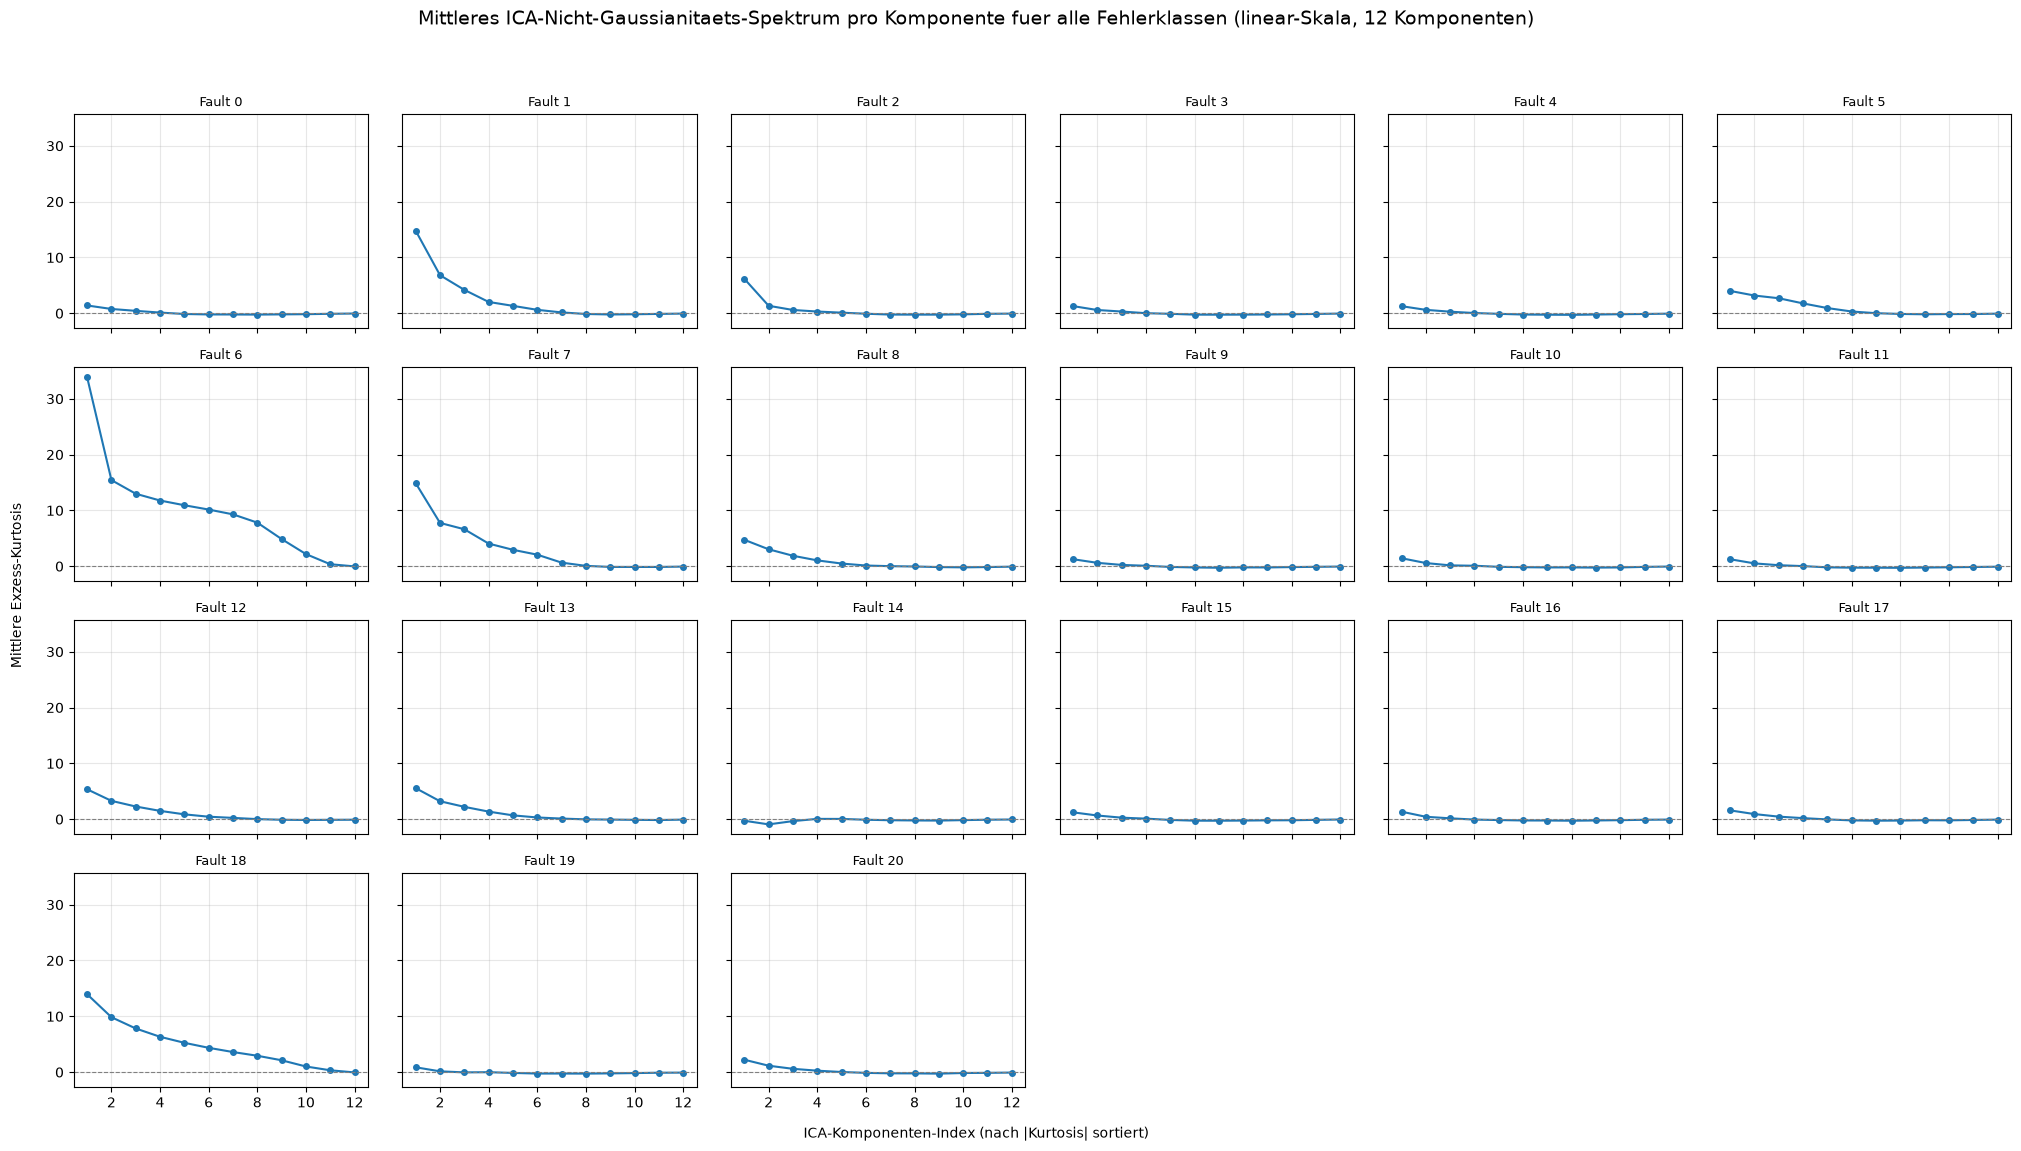

In [10]:
# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der mittlere
# Spektrumsverlauf ueber die N_ICA Komponenten.
# ============================================================

# Alle N_ICA Komponenten darstellen (12 sind uebersichtlich genug;
# bei PCA/DyCA begrenzen k_max/K_MAX das 52er-Spektrum).
K_MAX_ICA = N_ICA


# ============================================================
# Hilfsfunktion: Transformation der Werte vor dem Plotten
# ============================================================
def transform_eigenvalues(vals, mode="linear"):
    """
    Transformiert einen Vektor von Spektrums-Werten fuer die Darstellung.

    mode = "linear"   -> keine Transformation. STANDARD fuer dieses
                         Notebook: Kurtosis-Werte koennen NEGATIV sein
                         (sub-gaussisch), eine lineare Achse zeigt das
                         Vorzeichen direkt.
    mode = "log"      -> log10(max(Wert, eps)). ACHTUNG: schneidet
                         negative Werte bei eps ab - nur sinnvoll, wenn
                         ausschliesslich |Kurtosis| interessiert.
    mode = "relative" -> Wert / Wert_1. Zeigt nur das "Profil" des
                         Spektrums.
    """
    vals = np.asarray(vals, dtype=float)

    if mode == "linear":
        return vals

    if mode == "log":
        eps = 1e-8
        return np.log10(np.maximum(vals, eps))

    if mode == "relative":
        if vals[0] == 0:
            return vals
        return vals / vals[0]

    raise ValueError(f"Unbekannter mode: {mode}")


# Darstellungsmodus - bewusst "linear" (Vorzeichen sichtbar, s.o.).
plot_mode = "linear"


def plot_ica_means_per_fault(agg_df, eig_prefix="ica_", k_max=K_MAX_ICA):
    eig_cols_mean = [
        c for c in agg_df.columns
        if c.startswith(eig_prefix) and c.endswith("_mean")
    ]
    eig_cols_mean = sorted(eig_cols_mean, key=lambda c: int(c.split("_")[1]))
    eig_cols_mean = eig_cols_mean[:k_max]
    K = len(eig_cols_mean)

    faults   = np.sort(agg_df["faultNumber"].unique())
    n_faults = len(faults)

    ncols = 6
    nrows = int(np.ceil(n_faults / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.5 * ncols, 3.0 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    x = np.arange(1, K + 1)

    for i, fault in enumerate(faults):
        ax  = axes[i]
        row = agg_df[agg_df["faultNumber"] == fault].iloc[0]

        y      = np.array([row[c] for c in eig_cols_mean], dtype=float)
        y_vals = transform_eigenvalues(y, mode=plot_mode)

        ax.plot(x, y_vals, "o-", markersize=4)
        # Nulllinie: trennt super-gaussisch (oben) von sub-gaussisch (unten).
        ax.axhline(0.0, color="grey", linestyle="--", linewidth=0.8)
        ax.set_title(f"Fault {fault}", fontsize=9)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    if plot_mode == "log":
        y_label = "log10(Mittlere Exzess-Kurtosis)"
    elif plot_mode == "relative":
        y_label = "Mittlere Exzess-Kurtosis / ica_1"
    else:
        y_label = "Mittlere Exzess-Kurtosis"

    fig.suptitle(
        f"Mittleres ICA-Nicht-Gaussianitaets-Spektrum pro Komponente fuer "
        f"alle Fehlerklassen ({plot_mode}-Skala, {K} Komponenten)",
        fontsize=14,
    )
    fig.text(0.5,  0.04, "ICA-Komponenten-Index (nach |Kurtosis| sortiert)",
             ha="center")
    fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

    plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
    plt.show()


plot_ica_means_per_fault(agg)

# Visualisierung: Standardabweichungs-Spektren je Fehlerklasse #

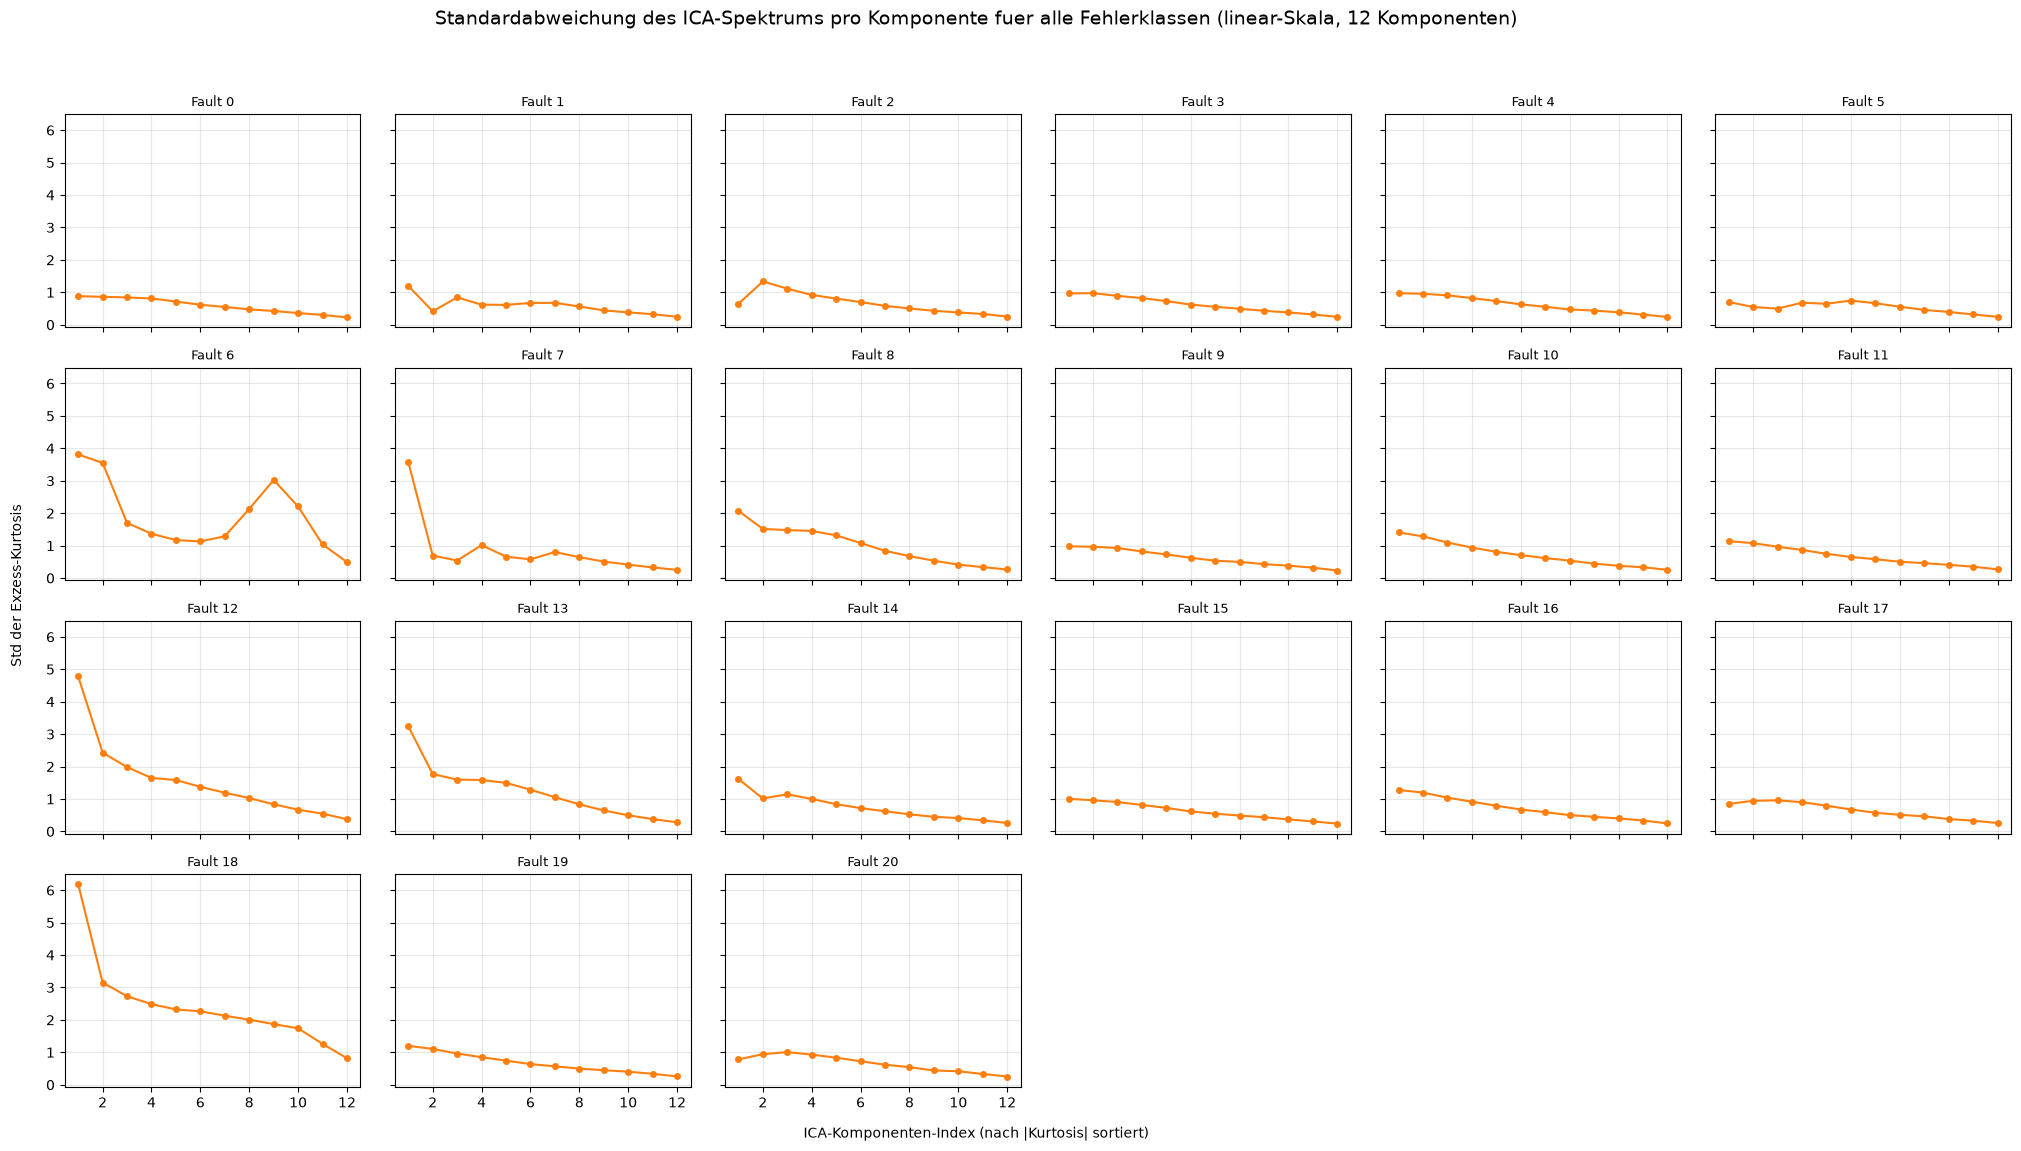

In [11]:
# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der Verlauf
# der STANDARDABWEICHUNG der Spektrums-Werte ueber die Komponenten.
# Struktur identisch zum Mittelwerts-Plot, orange Linienfarbe.
# K_MAX_ICA, transform_eigenvalues und plot_mode kommen aus der
# Mittelwerts-Zelle.
# ============================================================

def plot_ica_stds_per_fault(agg_df, eig_prefix="ica_", k_max=K_MAX_ICA):
    eig_cols_std = [
        c for c in agg_df.columns
        if c.startswith(eig_prefix) and c.endswith("_std")
    ]
    eig_cols_std = sorted(eig_cols_std, key=lambda c: int(c.split("_")[1]))
    eig_cols_std = eig_cols_std[:k_max]
    K = len(eig_cols_std)

    faults   = np.sort(agg_df["faultNumber"].unique())
    n_faults = len(faults)

    ncols = 6
    nrows = int(np.ceil(n_faults / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.5 * ncols, 3.0 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    x = np.arange(1, K + 1)

    for i, fault in enumerate(faults):
        ax  = axes[i]
        row = agg_df[agg_df["faultNumber"] == fault].iloc[0]

        y      = np.array([row[c] for c in eig_cols_std], dtype=float)
        y_vals = transform_eigenvalues(y, mode=plot_mode)

        ax.plot(x, y_vals, "o-", color="tab:orange", markersize=4)
        ax.set_title(f"Fault {fault}", fontsize=9)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    if plot_mode == "log":
        y_label = "log10(Std der Exzess-Kurtosis)"
    elif plot_mode == "relative":
        y_label = "Std_i / Std_1"
    else:
        y_label = "Std der Exzess-Kurtosis"

    fig.suptitle(
        f"Standardabweichung des ICA-Spektrums pro Komponente fuer alle "
        f"Fehlerklassen ({plot_mode}-Skala, {K} Komponenten)",
        fontsize=14,
    )
    fig.text(0.5,  0.04, "ICA-Komponenten-Index (nach |Kurtosis| sortiert)",
             ha="center")
    fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

    plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
    plt.show()


plot_ica_stds_per_fault(agg)

# Visualisierung: relative Streuung (Variationskoeffizient) je Fehlerklasse #

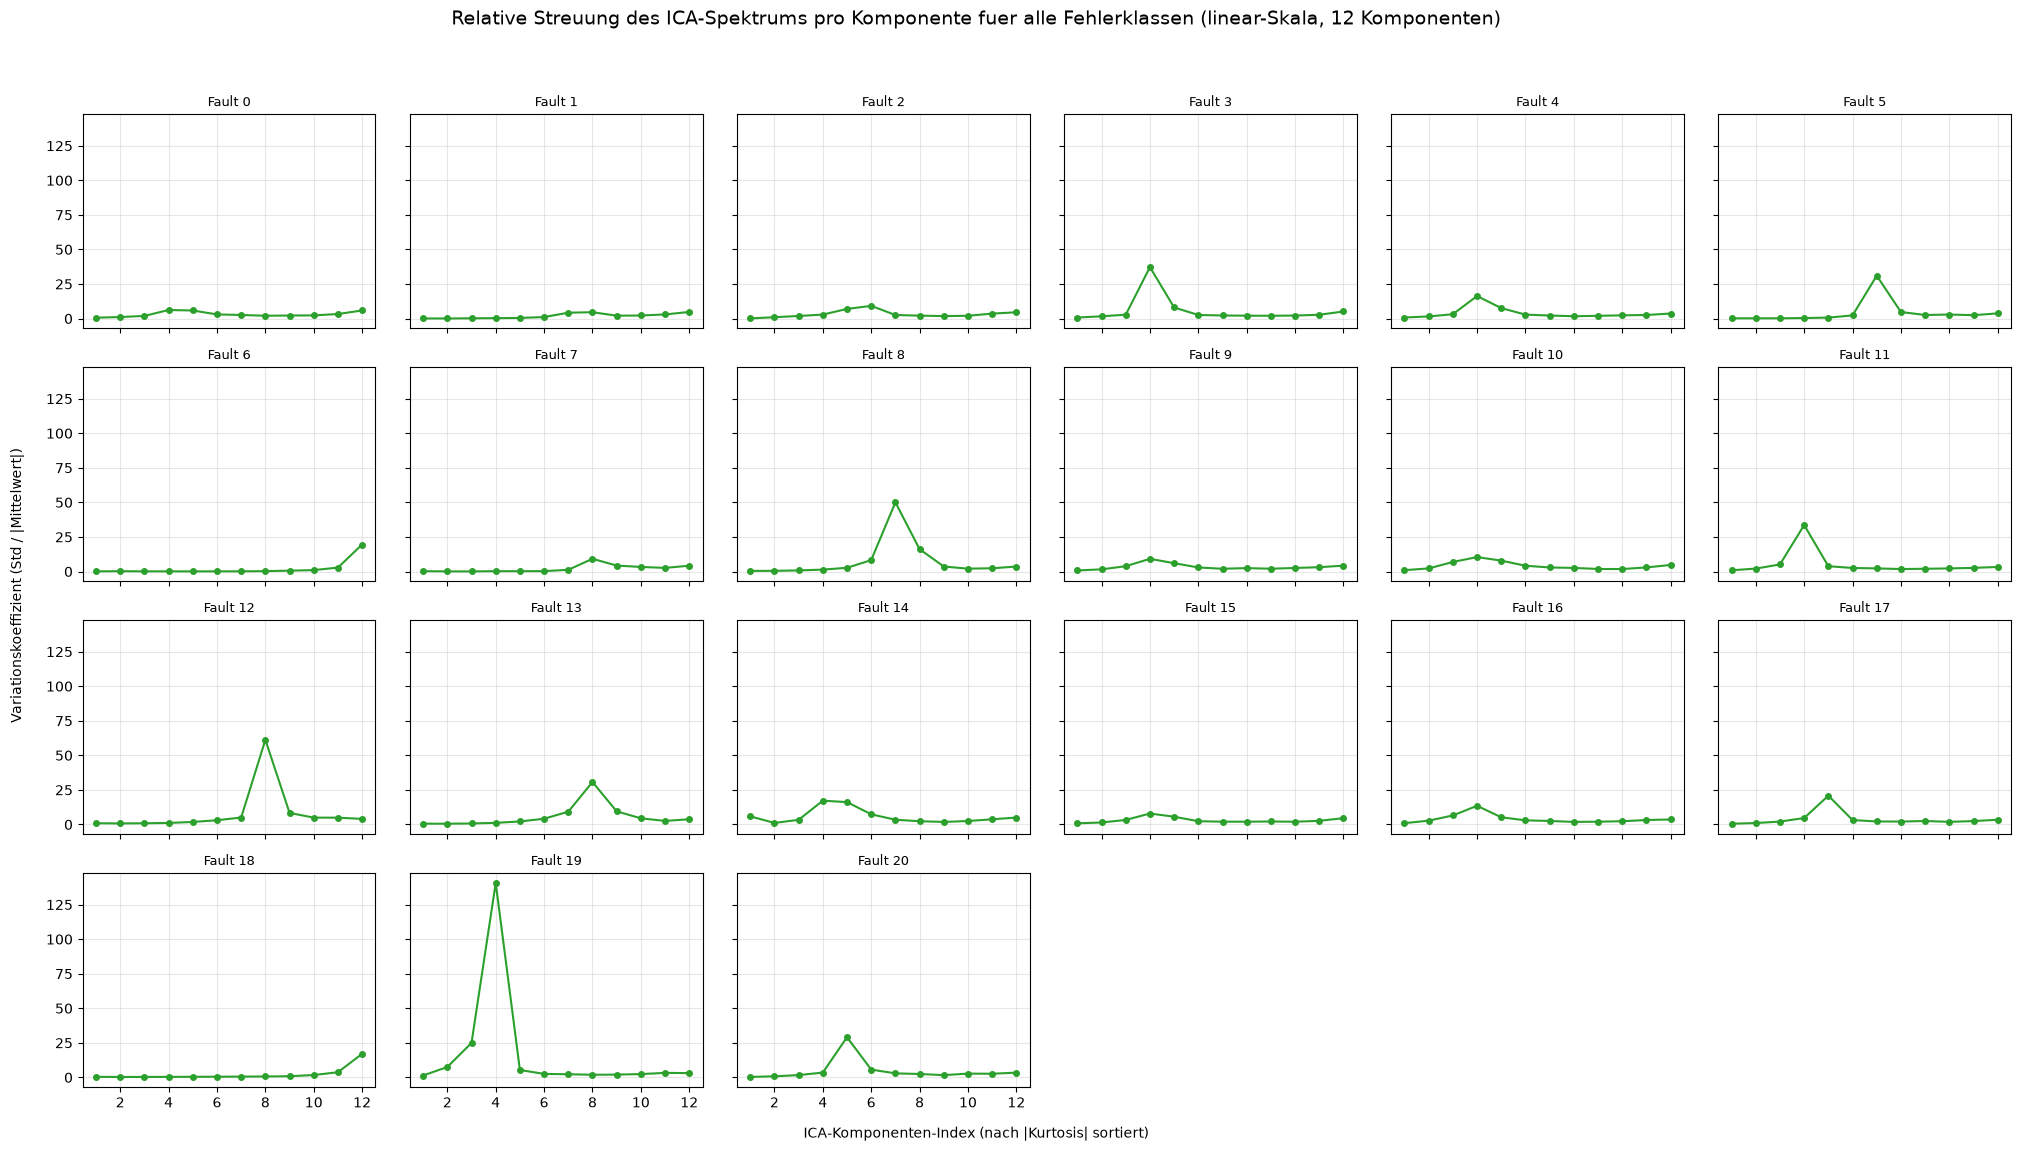

In [12]:
# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der Verlauf
# der RELATIVEN STREUUNG der Spektrums-Werte ueber die Komponenten.
#
#     CV_i = ica_i_std / |ica_i_mean|
#
# ABWEICHUNG von PCA/DyCA: der Nenner ist der BETRAG des Mittelwerts,
# weil die Kurtosis-Mittelwerte negativ sein koennen - ein negativer
# CV waere nicht interpretierbar. Bei Mittelwerten nahe 0 (Klassen, in
# denen sich super- und sub-gaussische Runs mischen) explodiert der CV;
# solche Punkte sind mit Vorsicht zu lesen.
# ============================================================

plot_mode_cv = "linear"


def plot_ica_cv_per_fault(agg_df, eig_prefix="ica_", k_max=K_MAX_ICA):
    eig_cols_mean = [
        c for c in agg_df.columns
        if c.startswith(eig_prefix) and c.endswith("_mean")
    ]
    eig_cols_std  = [
        c for c in agg_df.columns
        if c.startswith(eig_prefix) and c.endswith("_std")
    ]
    eig_cols_mean = sorted(eig_cols_mean, key=lambda c: int(c.split("_")[1]))
    eig_cols_std  = sorted(eig_cols_std,  key=lambda c: int(c.split("_")[1]))

    eig_cols_mean = eig_cols_mean[:k_max]
    eig_cols_std  = eig_cols_std[:k_max]
    K = len(eig_cols_mean)

    faults   = np.sort(agg_df["faultNumber"].unique())
    n_faults = len(faults)

    ncols = 6
    nrows = int(np.ceil(n_faults / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.5 * ncols, 3.0 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    x = np.arange(1, K + 1)

    for i, fault in enumerate(faults):
        ax  = axes[i]
        row = agg_df[agg_df["faultNumber"] == fault].iloc[0]

        mean_vals = np.array([row[c] for c in eig_cols_mean], dtype=float)
        std_vals  = np.array([row[c] for c in eig_cols_std],  dtype=float)

        # CV mit |Mittelwert| im Nenner (siehe Kommentar oben).
        with np.errstate(divide="ignore", invalid="ignore"):
            cv = np.where(np.abs(mean_vals) > 0,
                          std_vals / np.abs(mean_vals), np.nan)

        y_vals = transform_eigenvalues(cv, mode=plot_mode_cv)

        ax.plot(x, y_vals, "o-", color="tab:green", markersize=4)
        ax.set_title(f"Fault {fault}", fontsize=9)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    if plot_mode_cv == "log":
        y_label = "log10(CV) = log10(Std / |Mittelwert|)"
    elif plot_mode_cv == "relative":
        y_label = "CV_i / CV_1"
    else:
        y_label = "Variationskoeffizient (Std / |Mittelwert|)"

    fig.suptitle(
        f"Relative Streuung des ICA-Spektrums pro Komponente fuer alle "
        f"Fehlerklassen ({plot_mode_cv}-Skala, {K} Komponenten)",
        fontsize=14,
    )
    fig.text(0.5,  0.04, "ICA-Komponenten-Index (nach |Kurtosis| sortiert)",
             ha="center")
    fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

    plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
    plt.show()


plot_ica_cv_per_fault(agg)

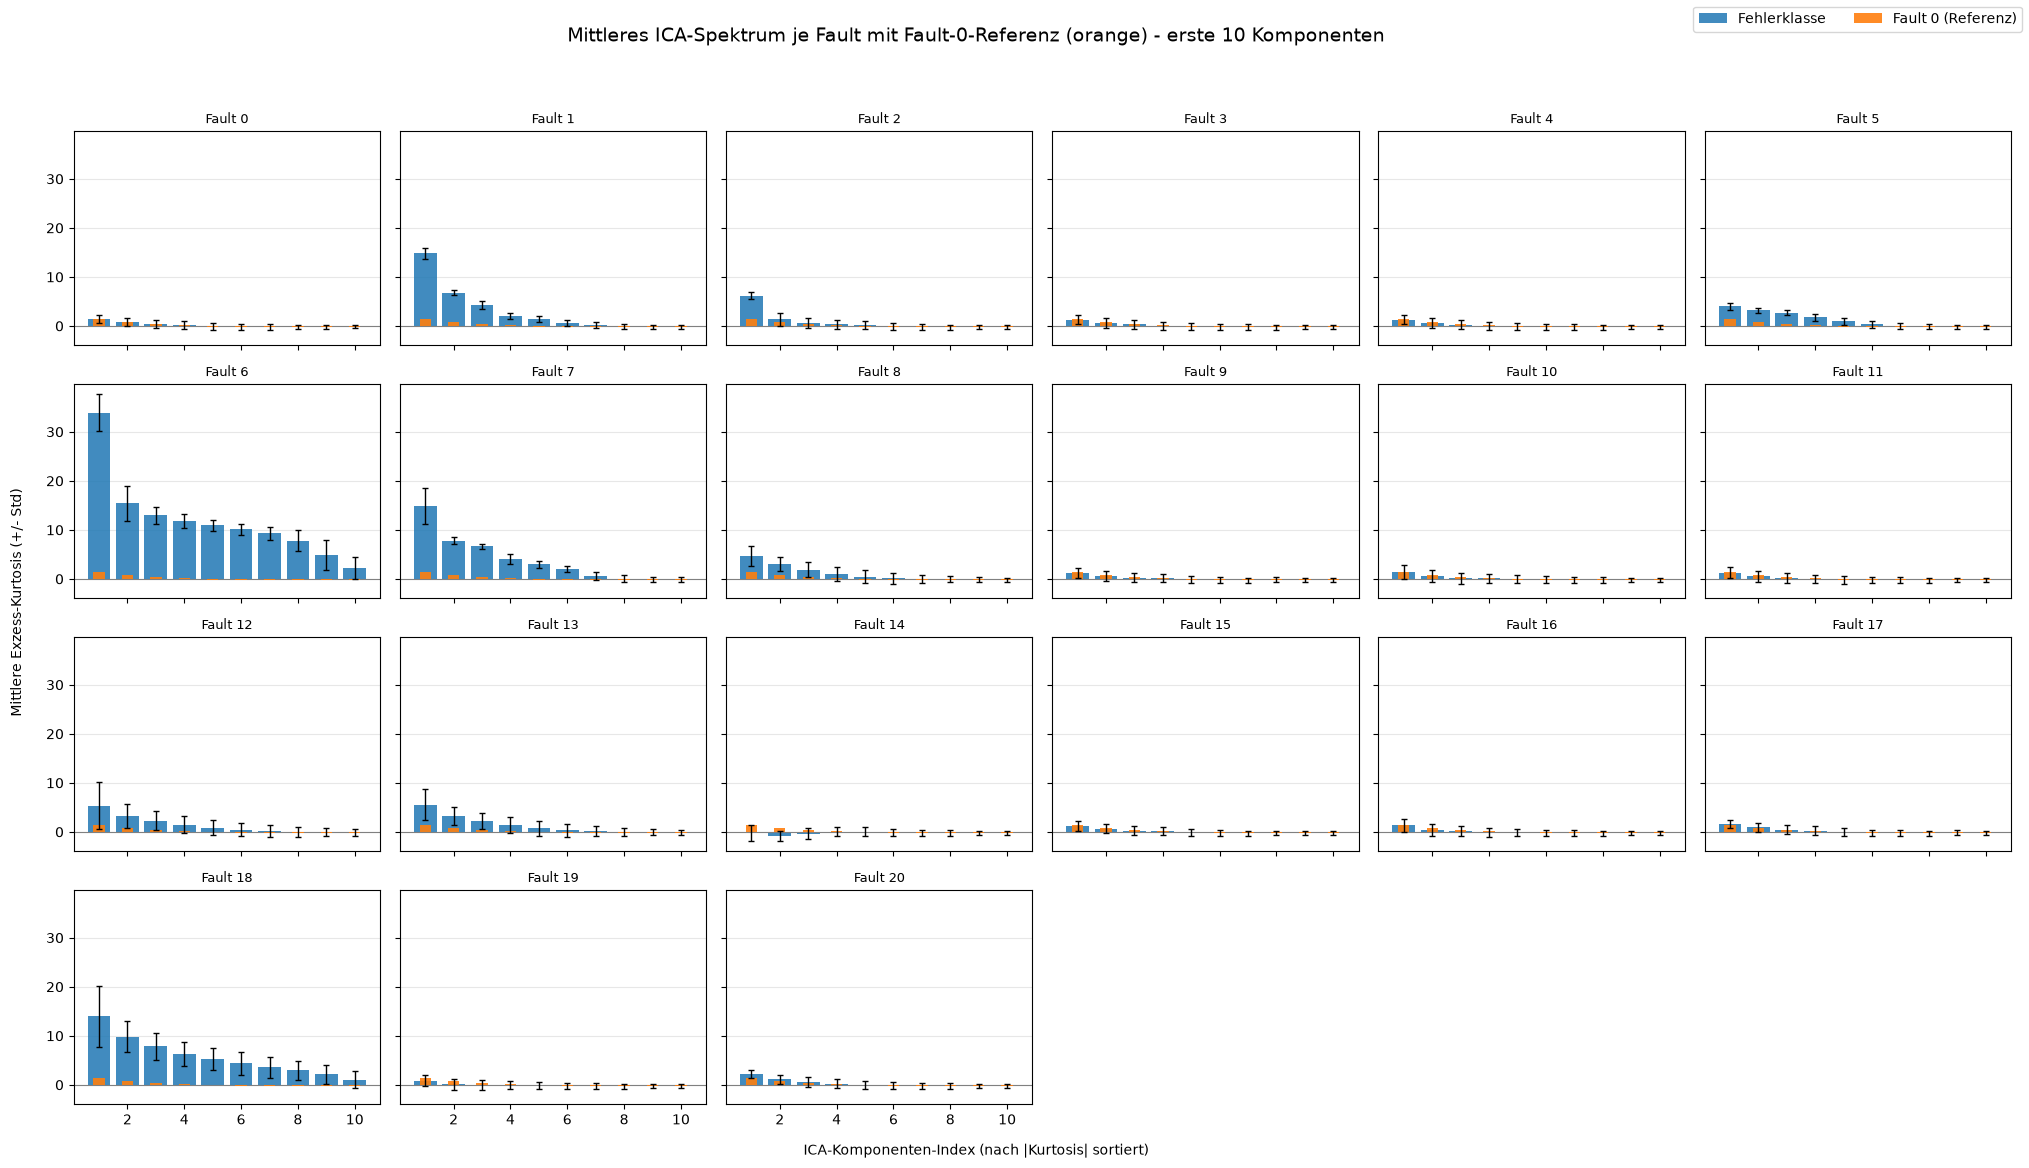

In [13]:
# ============================================================
# Bar-Plot: ICA-Spektrum je Fault MIT Fault-0-Overlay
# ============================================================
# Pro Fehlerklasse ein Subplot:
#   - breite blaue Balken  = mittlere Exzess-Kurtosis der Klasse,
#   - schmale orange Balken= Mittelwert von Fault 0 (Normalbetrieb),
#                            zentriert oben drauf als Referenz,
#   - schwarze Fehlerbalken= +/- Std ueber die Runs der Klasse, werden
#                            ZULETZT gezeichnet (hoechster zorder).
# Balken koennen hier - anders als bei PCA/DyCA - auch nach UNTEN zeigen
# (sub-gaussische Komponenten, Kurtosis < 0).

def plot_ica_bars_with_ref(agg_df, eig_prefix="ica_", k_bar=10):
    mean_cols_bar = [f"{eig_prefix}{i}_mean" for i in range(1, k_bar + 1)]
    std_cols_bar  = [f"{eig_prefix}{i}_std"  for i in range(1, k_bar + 1)]

    faults   = np.sort(agg_df["faultNumber"].unique())
    n_faults = len(faults)
    ncols    = 6
    nrows    = int(np.ceil(n_faults / ncols))

    # Referenz-Spektrum: Mittelwerte von Fault 0 (Normalbetrieb).
    ref_means = agg_df[agg_df["faultNumber"] == 0].iloc[0][mean_cols_bar].values.astype(float)

    x = np.arange(1, k_bar + 1)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.5 * ncols, 3.0 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    for i, f in enumerate(faults):
        ax  = axes[i]
        row = agg_df[agg_df["faultNumber"] == f].iloc[0]
        means = row[mean_cols_bar].values.astype(float)
        stds  = row[std_cols_bar].values.astype(float)

        ax.bar(x, means, width=0.8,
               color="C0", alpha=0.85,
               label="Fehlerklasse", zorder=2)
        ax.bar(x, ref_means, width=0.4,
               color="tab:orange", alpha=0.9,
               label="Fault 0 (Referenz)", zorder=3)
        ax.errorbar(x, means, yerr=stds, fmt="none",
                    ecolor="black", capsize=2, elinewidth=1, zorder=4)
        ax.axhline(0.0, color="grey", linewidth=0.8)

        ax.set_title(f"Fault {f}", fontsize=9)
        ax.grid(True, axis="y", alpha=0.3)

    for j in range(n_faults, len(axes)):
        axes[j].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=2, fontsize=10)

    fig.suptitle(
        f"Mittleres ICA-Spektrum je Fault mit Fault-0-Referenz (orange) "
        f"- erste {k_bar} Komponenten",
        fontsize=14,
    )
    fig.text(0.5,  0.04, "ICA-Komponenten-Index (nach |Kurtosis| sortiert)",
             ha="center")
    fig.text(0.04, 0.5,  "Mittlere Exzess-Kurtosis (+/- Std)",
             va="center", rotation="vertical")

    plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
    plt.show()


plot_ica_bars_with_ref(agg)

In [14]:
# ============================================================
# Export: ICA-Spektrum (Training) als CSV
# ============================================================
# Stellt die TRAININGS-Spektren fuer ein LazyClassifier-Notebook bereit.
# Die TEST-Spektren werden bewusst NICHT hier berechnet, sondern -
# analog zu LazyClassifier_PCA_DyCA.ipynb - dort mit Cutoff 161 und
# Fenster-Angleich; dieses Notebook bleibt training-only.
# Die Spalte 'converged' ist eine Diagnose-Spalte, kein Feature - der
# ica_-Prefix-Filter beim Einlesen laesst sie automatisch aussen vor.
ica_spectrum_per_run.to_csv("ica_eigenvalues_train.csv", index=False)
print("ICA-Train gespeichert:", ica_spectrum_per_run.shape,
      "-> ica_eigenvalues_train.csv")

ICA-Train gespeichert: (10500, 15) -> ica_eigenvalues_train.csv
